In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import pandas as pd
from scipy.fft import fft, fftfreq
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import scipy
cm_number = 10
cm = plt.cm.get_cmap("tab10")
colors = [cm(1. / (cm_number - 1) * i) for i in range(0, cm_number)]
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset, zoomed_inset_axes
mpl.rc('font', family='Arial')
mpl.rc('font',size = 8)
mpl.rc('mathtext',fontset = 'stix')
mpl.rc('xtick', labelsize=6)
mpl.rc('ytick', labelsize=6)
# mpl.rc('xtick', labelsize=4)
# mpl.rc('ytick', labelsize=4)
mpl.rc('axes', labelsize=8)
mpl.rc('axes', labelpad=1)
mpl.rc('axes', titlesize=8)
mpl.rc('axes', linewidth=0.5)

In [4]:
def xlcc2frf_mirror(xlcc,Modeshape, node):
    d1, d2 = np.shape(xlcc)
    num = 3
    orbit_len = (d1-2-2-num*2)//(num*2+2)
    frfs_amplitude = np.zeros(d2)
    frfs_phase = np.zeros(d2)
    for j in range(d2):
        orbits = np.zeros([orbit_len,num])
        cos = xlcc[7:-((num+1)*2)-2+7:(num+1)*2,j]
        sin = xlcc[6:-((num+1)*2)-2+6:(num+1)*2,j]
        theta = np.linspace(0, 2*np.pi, len(cos), endpoint=False)
        for i in range(num):
            orbits[:,i] = xlcc[i*2:-((num+1)*2)-2+i*2:(num+1)*2, j]
        orbit_e2 = np.sum(orbits * Modeshape[node-1,:3], axis = 1)
        orbit_e3 = np.sum(orbits * Modeshape[node,:3], axis = 1)
        # frfs_orbit =  2*np.degrees(np.arctan2(np.sqrt2(orbit_e2**2 + orbit_e3**2)/2,950))
        frfs_orbit =  np.degrees(np.arctan2(orbit_e3,900))
        # plt.plot(frfs_orbit)
        frfs_amplitude[j] = (np.max(frfs_orbit) - np.min(frfs_orbit))/2
        A = 2 * np.trapz(frfs_orbit*cos, theta)
        B = 2 * np.trapz(frfs_orbit*sin, theta)
        frfs_phase[j] = np.arctan2(B, A)
    return xlcc[-1,:-1], frfs_amplitude[:-1], frfs_phase[:-1]

In [5]:
datadir = r'C:\Users\TengMa\OneDrive\POLIMI\1. MEMS SINDy\wetransfer_data_perseus_2025-05-16_1416\data_perseus'
positionname = 'sindy_perseus_S_FRF_IC0.mat'
velocityname = 'sindy_perseus_S_vel_FRF_IC0.mat'
datafile = "%s/%s"%(datadir, positionname)
P = "%s/%s"%(datadir, 'sindy_perseus_I_FRF_IC0.mat')
POM = "%s/%s"%(datadir, 'POM.mat')
import h5py
with h5py.File(datafile, 'r') as file:
    data = np.array(file['S'])
with h5py.File(P, 'r') as file:
    p = np.array(file['I'])
timestamp = 99999
timeeffect = 99999
Modes = 3
Modeshape = scipy.io.loadmat(POM)["POM"]
node = 4526
POM_1 = Modeshape[node,:3]


Omegas_FOMs = []
response_FOMs = []

node = 4526
POM_1 = Modeshape[node,:3]
Omegas_ROMs = []
response_ROMs = []
PROJECT = r"../matcont_solver/"   # 改成你的路径
betas = [1.0,1.5,2.0,2.5,3.0]
trainset = pd.read_csv("../../Validation/Micromirror2/trainset.csv")

# FOM obtaining
for i in range(len(betas)):
    file = "../../Validation//Micromirror2/beta%.1f-1.csv"%betas[i]
    data_FOM = pd.read_csv(file, header = None)
    Omegas_FOMs.append(data_FOM[0])
    response_FOMs.append(data_FOM[1])


Omegas_FOM_P = []
Phases_FOM = []
for i in range(len(betas)):
    file = "../../Validation//Micromirror2/beta%.1f-1-P.csv"%betas[i]
    data_FOM_P = pd.read_csv(file, header = None)
    Phases_FOM.append(data_FOM_P[0])
    Omegas_FOM_P.append(data_FOM_P[1])

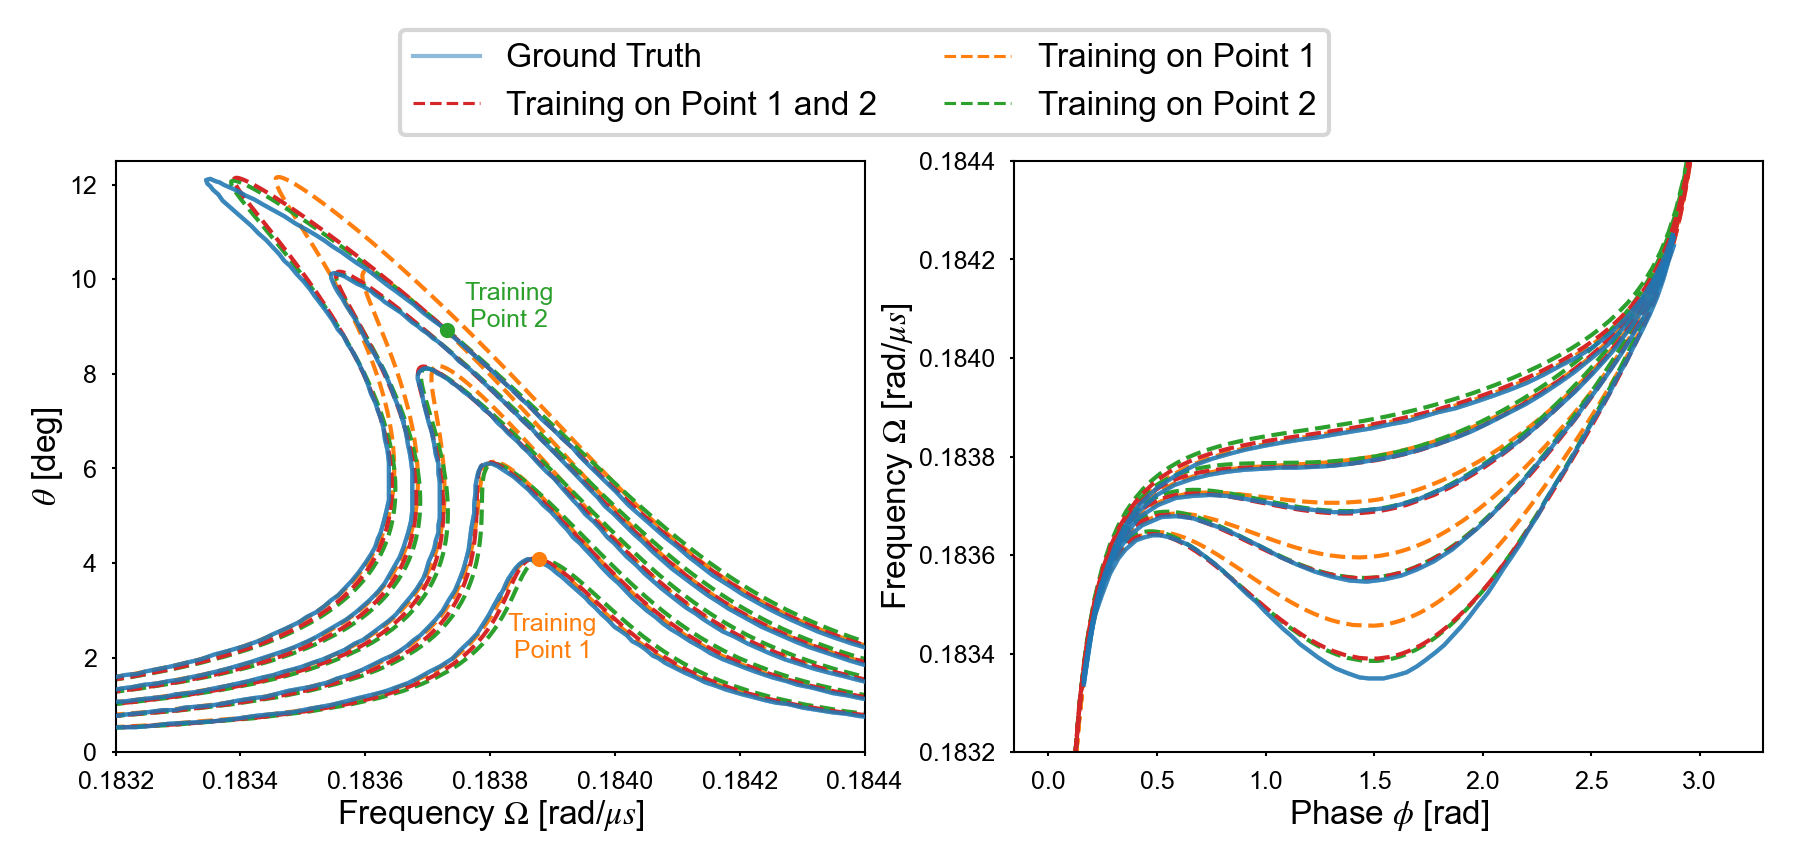

In [43]:
fig, axes = plt.subplots(1,2,figsize = (18/2.54, 6.5/2.54),width_ratios=[0.5,0.5],dpi = 300)
models = ['Mirror_POM3_6','Mirror_POM3_21','Mirror_POM3_6_21']
trainnum = [6,21,6]
cm_number = 10
cm = plt.cm.get_cmap("tab10")
colors = [cm(1. / (cm_number - 1) * i) for i in range(0, cm_number)]

for num in range(3):
    
    ax = axes[0]
    model_num = trainnum[num]
    Train_FREQ = trainset['omegas'][model_num]
    Train_FRF = trainset['As'][model_num]

    Omegas_ROM = []
    responses_ROM = []
    responses_ROM_P = []
    model = models[num]
    for A in betas:
        y = scipy.io.loadmat('%s/results/%s_A_%.5f'%(PROJECT,model,A/2))
       
        
        y = y['xlcc']
        freq, frf_A, frf_P = xlcc2frf_mirror(y, Modeshape, 4526)
        Omegas_ROM.append(freq)
        responses_ROM.append(frf_A)
        responses_ROM_P.append(frf_P)
    for i in range(len(betas)):
        ax.plot(Omegas_ROM[i], responses_ROM[i],color = colors[num+1],lw = 1,ls = '--', alpha = 1)
        ax.plot(Omegas_FOMs[i], response_FOMs[i], lw = 1,alpha = 0.5,color = colors[0],zorder = 100)
    # ax.plot(freq, frf)
    if num<2:
        ax.scatter([Train_FREQ],[Train_FRF], color = colors[num+1], s = 7,zorder = 200)
    ax.set_ylim(0,12.5)
    ax.set_xlim(0.1832,0.1844)
    ax.tick_params(direction='out',width = 0.5,length = 1)
    ax.set_xlabel("Frequency $\Omega$ [rad/$\mu s$]")
    ax.set_ylabel(r"$\theta$ [deg]")
    cmap_discrete = mpl.colors.ListedColormap(colors[4:])
    bounds = list(range(4, cm_number+1))
    norm = mpl.colors.BoundaryNorm(bounds, cmap_discrete.N)
    
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_discrete)
    sm.set_array([])
    tick_positions = [3.5, 4.5, 5.5, 6.5, 7.5]
# 你可以根据实际意义随意改 label 文本
    tick_labels = ['1.0$\mu$N','1.5$\mu$N','2.0$\mu$N','2.5$\mu$N','3.0$\mu$N']  
    # tick_positions = [4.5, 5.5, 6.5, 7.5, 8.5, 9.5,10.5,11.5,12.5,13.5,14.5,15.5]
    # tick_labels = ['0.0938$\mu$N','0.1250$\mu$N','0.1562$\mu$N','0.1875$\mu$N','0.2188$\mu$N','0.2500$\mu$N','0.2812$\mu$N','0.3125$\mu$N','0.375$\mu$N','0.5$\mu$N','0.625$\mu$N','0.75$\mu$N']  
    ax.tick_params(direction='out',width = 0.5,length = 1)
    
    ax = axes[1]
    
    for i in range(len(betas)):
        ax.plot(responses_ROM_P[i]+np.pi,Omegas_ROM[i],color = colors[num+1],lw = 1,ls = '--', alpha = 1)
        # if i<len(As)-1:
        ax.plot(Phases_FOM[i], Omegas_FOM_P[i], lw = 1,alpha = 0.5,color = colors[0],zorder = 100)
    # ax.set_xlim(0,3.2)
    ax.set_ylim(0.1832,0.1844)
    ax.tick_params(direction='out',width = 0.5,length = 1)
    ax.set_xlabel("Phase $\phi$ [rad]")
    ax.set_ylabel("Frequency $\Omega$ [rad/$\mu s$]")


ax.plot([0,0],[1,1],ls = '-',alpha = 0.5,lw = 1,color = colors[0],label = 'Ground Truth')
ax.plot([0,0],[1,1],ls = '--',alpha = 1,lw = 0.75,color = colors[3],label = 'Training on Point 1 and 2')
ax.plot([0,0],[1,1],ls = '--',alpha = 1,lw = 0.75,color = colors[1],label = 'Training on Point 1')
ax.plot([0,0],[1,1],ls = '--',alpha = 1,lw = 0.75,color = colors[2],label = 'Training on Point 2')


ax.legend(ncol = 2,loc = 'upper center',bbox_to_anchor = (-0.2,1.25))

ax = axes[0]
ax.text(0.1839,2,"Training\nPoint 1",fontsize = 6,color = colors[1],ha = 'center')
ax.text(0.18383,9,"Training\nPoint 2",fontsize = 6,color = colors[2],ha = 'center')

plt.savefig('./Mirrors/Figure/FRF_comparsion_MP.png',dpi = 300,transparent = True,bbox_inches="tight")

In [53]:
for model in models:
    # model = 'Mirror_POM3_%d'%num
    Omegas_ROM = []
    responses_ROM = []
    responses_ROM_P = []
    for A in [1,1.5,2,2.5,3]:
        y = scipy.io.loadmat('%s/results/%s_A_%.5f'%(PROJECT,model,A/2))
       
        
        y = y['xlcc']
        freq, frf_A, frf_P = xlcc2frf_mirror(y, Modeshape, 4526)
        # Omegas_ROM.append(freq)
        # responses_ROM.append(frf_A)
        # responses_ROM_P.append(frf_P)
    # Omegas_ROM.append(freq)
    # responses_ROM.append(frf_A)
    # responses_ROM_P.append(frf_P)
        stp = 0
        enp = -1
        while freq[stp]>0.1842:
            stp += 1
        while freq[enp]<0.1834:
            enp -=1
        results = {
            'Freq':freq[stp:enp],
            'Amplitude':frf_A[stp:enp],
            'Phase':frf_P[stp:enp]
        }
        pd.DataFrame(results).to_csv('./Mirrors/FRF/beta_%.4f_%s.csv'%(A,model))

In [44]:
As = [1,1.5,2,2.5,3]
Omegas_FOM = []
Amplitudes_FOM = []

# FOM obtaining
for i in range(len(As)):
    file = "../../Validation/Micromirror2/beta%.1f-1.csv"%As[i]
    data_FOM = pd.read_csv(file, header = None)
    Omegas_FOM.append(data_FOM[0])
    Amplitudes_FOM.append(data_FOM[1])

Omegas_FOM_P = []
Phases_FOM = []
for i in range(len(As)):
    file = "../../Validation/Micromirror2/beta%.1f-1-P.csv"%As[i]
    data_FOM_P = pd.read_csv(file, header = None)
    Phases_FOM.append(data_FOM_P[0])
    Omegas_FOM_P.append(data_FOM_P[1])

In [54]:
import sys
import pandas as pd
sys.path.append("../")
import importlib
import util
import numpy as np
importlib.reload(util)  # 重新载入
Project = './Mirrors/'
mean_chamfer_mirror = np.ones([3,5,2])
As_ranges = [[0.01,4],[0.01,6],[0.01,8],[0.01,10],[0.01,12]]
for i in range(len(models)):
    model = models[i]
    result_i = pd.read_csv('%s/FRF/beta_%.4f_%s.csv'%(Project,A,model))
    P_range = [0.01,3]
    for j in range(5):
        C_A_ref = np.array([Omegas_FOM[j], Amplitudes_FOM[j]]).T
        C_P_ref = np.array([Omegas_FOM_P[j], Phases_FOM[j]]).T
        A = As[j]
        result_i = pd.read_csv('%s/FRF/beta_%.4f_model_%d.csv'%(Project,A,i))
        C_A = np.array([result_i['Freq'],result_i['Amplitude']]).T
        C_P = np.array([result_i['Freq'],result_i['Phase']+np.pi]).T
        mean_chamfer_mirror[i,j,0] = np.mean(util.chamfer_oneway(C_A, C_A_ref, As_ranges[j]))
        mean_chamfer_mirror[i,j,1] = np.mean(util.chamfer_oneway(C_P, C_P_ref, P_range))
    

In [58]:
for i in range(3):
    print(models[i])
    print(np.mean(np.sum(mean_chamfer_mirror[i,:2,:], axis = 1), axis = 0))
    print(np.mean(np.sum(mean_chamfer_mirror[i,2:,:], axis = 1), axis = 0))

Mirror_POM3_6
0.012397582273167613
0.013301230118887878
Mirror_POM3_21
0.012215437531175398
0.01276653295051639
Mirror_POM3_6_21
0.010951168921260586
0.012221602780265349
